In [1]:
# -*- coding: utf-8 -*-
# Visual–Temporal Time Cell Modeling (Variable-Length Trajectories)
# 读取 **可变长度轨迹数据**（每条轨迹独立文件夹，包含 pkl + 图像序列），并结合 CNN + LSTM 进行视觉时间联合建模。

import os
import pickle
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import warnings

In [2]:


# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Dataset Definition (Cell 2) ---
class VariableLengthTrajectoryDataset(Dataset):
    def __init__(self, root_dir, transform=None, use_yaw=True, min_len=1):
        self.root_dir = root_dir
        self.use_yaw = use_yaw
        self.min_len = min_len
        self.trajectories = sorted([
            os.path.join(root_dir, d)
            for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        self.transform = transform or transforms.Compose([
            transforms.Resize((64,64)),
            transforms.ToTensor()
        ])
        print(f"✅ Found {len(self.trajectories)} trajectories in {root_dir}")

        # 🧩 自动识别输出维度 (Position dimension only for target)
        if not self.trajectories:
             raise ValueError(f"No trajectories found in {root_dir}")

        sample_traj_path = os.path.join(self.trajectories[0], "traj_data.pkl")
        try:
            with open(sample_traj_path, 'rb') as f:
                sample_data = pickle.load(f)
        except FileNotFoundError:
             raise FileNotFoundError(f"traj_data.pkl not found in the first trajectory: {self.trajectories[0]}")
        except Exception as e:
            raise RuntimeError(f"Error loading sample pkl file: {e}")

        # Target dimension is usually just the position dimension
        self.target_dim = len(sample_data['position'][0])
        # Input feature dimension includes position and optionally yaw
        self.input_feature_dim = self.target_dim + (1 if self.use_yaw and 'yaw' in sample_data else 0)


        print(f"Loaded {len(self.trajectories)} trajectories from {root_dir}")
        print(f"Detected target_dim (position) = {self.target_dim}")
        print(f"Detected input_feature_dim (position + yaw={self.use_yaw}) = {self.input_feature_dim}")


    def __len__(self):
        return len(self.trajectories)

    def _load_traj(self, traj_path):
        pkl_path = os.path.join(traj_path, "traj_data.pkl")
        try:
            with open(pkl_path, 'rb') as f:
                data = pickle.load(f)
        except FileNotFoundError:
            print(f"Warning: traj_data.pkl not found in {traj_path}. Skipping.")
            return None, None
        except Exception as e:
            print(f"Warning: Error loading {pkl_path}: {e}. Skipping.")
            return None, None

        pos = np.array(data.get('position', []), dtype=np.float32)
        yaw_data = data.get('yaw')
        # Handle potential scalar yaw values if they occur
        if yaw_data is not None:
             if isinstance(yaw_data, (int, float)):
                 # If it's a single scalar, assume it applies to the whole trajectory (less likely)
                 # or perhaps only the first step. More robustly, assume it's per step.
                 # If len(pos) > 0, replicate; otherwise, handle empty case.
                 if len(pos) > 0:
                     yaw = np.full(len(pos), float(yaw_data), dtype=np.float32)
                 else:
                     yaw = np.array([], dtype=np.float32)

             elif isinstance(yaw_data, (list, np.ndarray)):
                 try:
                     # Attempt conversion, handling potential nested structures if needed
                     yaw = np.array(yaw_data, dtype=np.float32).flatten() # Flatten in case of nested lists/arrays
                 except ValueError:
                     print(f"Warning: Could not convert yaw data in {pkl_path} to float32 array. Skipping yaw.")
                     yaw = None
             else:
                  print(f"Warning: Unexpected type for yaw data in {pkl_path}: {type(yaw_data)}. Skipping yaw.")
                  yaw = None
        else:
            yaw = None


        if pos.size == 0:
            print(f"Warning: No position data found in {pkl_path}. Skipping.")
            return None, None

        # Ensure yaw has the same length as pos if it exists
        if yaw is not None and len(yaw) != len(pos):
             print(f"Warning: Mismatch between position ({len(pos)}) and yaw ({len(yaw)}) lengths in {pkl_path}. Using min length or skipping yaw.")
             min_len_traj = min(len(pos), len(yaw))
             if min_len_traj > 0:
                 pos = pos[:min_len_traj]
                 yaw = yaw[:min_len_traj]
             else:
                 # If lengths mismatch and one is zero, cannot proceed reliably
                 print(f"Skipping yaw due to length mismatch and potential zero length.")
                 yaw = None # Skip yaw if lengths mismatch significantly


        return pos, yaw


    def _load_imgs(self, traj_path):
        img_files = sorted([
            os.path.join(traj_path, f)
            for f in os.listdir(traj_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg')) # Added .jpeg
        ])
        imgs = []
        for f in img_files:
             try:
                 img = Image.open(f).convert('RGB')
                 imgs.append(self.transform(img))
             except Exception as e:
                 print(f"Warning: Could not load or transform image {f}: {e}. Skipping image.")
                 # Decide how to handle: either skip the whole trajectory or just this image.
                 # If skipping image, need to align pos/yaw later. For simplicity,
                 # let's return an empty list if any image fails, causing __getitem__ to handle it.
                 # return [] # Option 1: Skip trajectory if any image fails
                 pass # Option 2: Skip only the faulty image, requires alignment later

        return imgs


    def __getitem__(self, idx):
        while idx < len(self.trajectories): # Loop to find a valid trajectory
            traj_path = self.trajectories[idx]
            pos, yaw = self._load_traj(traj_path)

            if pos is None: # Trajectory loading failed
                 print(f"Skipping trajectory at index {idx} due to loading error: {traj_path}")
                 idx += 1 # Try next index
                 if idx == len(self.trajectories): return self.__getitem__(0) # Wrap around if needed, or raise error
                 continue # Go to next iteration of while loop

            imgs = self._load_imgs(traj_path)

            # Align lengths of pos, yaw (if used), and imgs
            n = len(pos)
            if self.use_yaw and yaw is not None:
                n = min(n, len(yaw))
            n = min(n, len(imgs))

            if n < self.min_len:
                 # print(f"Skipping trajectory {traj_path} (length {n} < min_len {self.min_len})")
                 idx += 1 # Try next index
                 if idx == len(self.trajectories): return self.__getitem__(0) # Wrap around or raise error
                 continue # Go to next iteration of while loop


            pos, imgs = pos[:n], imgs[:n]
            if self.use_yaw and yaw is not None:
                yaw = yaw[:n]
                # Ensure yaw has shape (n,) before adding dimension
                if yaw.ndim > 1:
                     yaw = yaw.flatten() # Or handle specific shape issues
                feats = np.concatenate([pos, yaw[:, None]], axis=1)
            else:
                feats = pos

            imgs_tensor = torch.stack(imgs)
            # Target is the final position (use actual pos dimension)
            target = torch.tensor(pos[-1, :self.target_dim], dtype=torch.float32)
            feats_tensor = torch.tensor(feats, dtype=torch.float32)

            return feats_tensor, imgs_tensor, target # Return the valid data

        # If loop finishes without finding a valid trajectory (should ideally not happen with wrap-around)
        raise IndexError(f"Could not find a valid trajectory after checking index {idx} onwards.")



Using device: cuda


In [3]:

# --- Collate Function (Cell 3) ---
def collate_variable_length(batch):
    # Filter out None items that might result from errors in __getitem__
    batch = [item for item in batch if item is not None]
    if not batch: # If all items in the batch failed
        return None, None, None, None # Or raise an error

    feats, imgs, targets = zip(*batch)

    # Check if lists are empty after filtering
    if not feats or not imgs or not targets:
        return None, None, None, None # Or raise an error

    lengths = [f.shape[0] for f in feats]
    max_len = max(lengths) if lengths else 0

    if max_len == 0: # Handle case where all valid trajectories have zero length (unlikely)
         return None, None, None, None

    feat_dim = feats[0].shape[1] if feats else 0
    img_shape = imgs[0].shape[1:] if imgs else (0, 0, 0) # Use shape directly

    feats_padded = torch.zeros(len(batch), max_len, feat_dim, dtype=torch.float32)
    imgs_padded = torch.zeros(len(batch), max_len, *img_shape, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, (f, im) in enumerate(zip(feats, imgs)):
        L = f.shape[0]
        if L > 0: # Ensure sequence length is positive
            feats_padded[i, :L] = f
            imgs_padded[i, :L] = im
            mask[i, :L] = True

    # Ensure targets are stacked correctly even if some items were filtered
    # targets list might contain tensors of different shapes if __getitem__ logic changes target dim
    # Assuming target is always the last position (fixed dim), stacking should work.
    try:
        targets = torch.stack(targets)
    except RuntimeError as e:
        print(f"Error stacking targets: {e}")
        # Handle error: maybe return None or pad targets if shape mismatch is expected
        return None, None, None, None


    return feats_padded, imgs_padded, targets, mask



In [ ]:

# --- Model Definition (Cell 4 - Optimized) ---
class VisualTemporalNet(nn.Module):
    def __init__(self, feature_dim=4, hidden_dim=128, visual_dim=256, output_dim=None):
        super().__init__()
        self.visual_dim = visual_dim
        self.hidden_dim = hidden_dim
        self.feature_dim = feature_dim # This is INPUT feature dim (pos+yaw)
        self.output_dim = output_dim # This is OUTPUT target dim (e.g., pos)


        # Simple CNN for visual feature extraction，输入视觉图像信号，输入，输出视觉特征向量
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, visual_dim), nn.ReLU()
        )

        # Initialize temporal_conv to None
        self.temporal_conv = None
        self.attn = nn.MultiheadAttention(embed_dim=visual_dim, num_heads=4, batch_first=True)
        # Input to LSTM should match output of attention layer (visual_dim)
        self.lstm = nn.LSTM(visual_dim, hidden_dim, batch_first=True)
        # Final FC layer output dimension should match the desired prediction target dimension
        self.fc = nn.Linear(hidden_dim, self.output_dim) # Use self.output_dim

    def forward(self, feats, imgs, mask):
        # Ensure model components are on the same device as input tensors
        current_device = imgs.device
        self.cnn.to(current_device)
        self.attn.to(current_device)
        self.lstm.to(current_device)
        self.fc.to(current_device)

        B, T, C, H, W = imgs.shape # Get C, H, W from input
        imgs_flat = imgs.view(B * T, C, H, W) # Reshape for batch processing by CNN
        vis_flat = self.cnn(imgs_flat)
        visual_feats = vis_flat.view(B, T, -1) # Reshape back to (B, T, visual_dim)

        # Ensure 'feats' are also on the correct device (handled in the loop/collate)
        feats = feats.to(current_device)
        mask = mask.to(current_device) # Ensure mask is on the correct device

        # Apply Temporal Conv and Attention ONLY to visual features
        temp_conv_input = visual_feats.transpose(1, 2) # (B, visual_dim, T)

        # Dynamically construct temporal_conv if needed, ensuring it's on the correct device
        # Check based on input channels needed
        if self.temporal_conv is None or self.temporal_conv.in_channels != self.visual_dim:
            # Make sure the dynamically created layer is on the same device as the model/data
            self.temporal_conv = nn.Conv1d(self.visual_dim, self.visual_dim, kernel_size=3, padding=1).to(current_device)

        temp_conv_output = F.relu(self.temporal_conv(temp_conv_input))
        processed_visual = temp_conv_output.transpose(1, 2) # (B, T, visual_dim)

        # Apply attention to the temporally processed visual features
        # key_padding_mask should mask PAD tokens (where mask is False)
        attn_out, _ = self.attn(processed_visual, processed_visual, processed_visual, key_padding_mask=~mask)

        # LSTM input is the output of the attention layer
        lstm_input = attn_out

        # Packing requires lengths on CPU
        lengths = mask.sum(1).cpu().to(torch.int64) # Ensure lengths are integer type
        # Check for zero lengths before packing
        if (lengths == 0).any():
             # Handle sequences with zero length if they occur, e.g., by skipping them or returning zeros
             # This might indicate an issue upstream in data loading or masking
             print("Warning: Detected sequences with zero length.")
             # Simple handling: return zeros of the expected shape
             pred = torch.zeros(B, self.output_dim, device=current_device)
             lstm_out = torch.zeros(B, T, self.hidden_dim, device=current_device)
             return pred, lstm_out


        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(lstm_input, lengths, batch_first=True, enforce_sorted=False)

        lstm_out_packed, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out_packed, batch_first=True, total_length=T) # Ensure padding back to max length T

        # Select the last valid hidden state for each sequence
        last_valid_indices = lengths - 1
        last_hidden_states = lstm_out[torch.arange(B, device=current_device), last_valid_indices] # Index on the correct device

        pred = self.fc(last_hidden_states)
        return pred, lstm_out

In [5]:
# --- Helper: Safe MSE Calculation (Cell 6 - Optimized) ---
def safe_mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Sample count mismatch: {y_true.shape[0]} vs {y_pred.shape[0]}")
    D_true, D_pred = y_true.shape[1], y_pred.shape[1]
    D_common = min(D_true, D_pred)
    if D_true != D_pred:
        warnings.warn(f"Dimension mismatch: y_true={D_true}, y_pred={D_pred}. Using first {D_common} dims.")
    # Ensure arrays are not empty before calculating mean
    if y_true.shape[0] == 0 or D_common == 0:
         return np.nan # Or return 0.0, depending on desired behavior for empty input
    mse = np.mean((y_true[:, :D_common] - y_pred[:, :D_common])**2)
    return mse

In [ ]:


# --- Analysis Function 1: analyze_time_cells (Cell 6 - Optimized) ---
def analyze_time_cells(model, loader, device, n_cells_to_plot=16): # Pass device
    model.eval()
    all_hidden_states = []

    # ---- Collect LSTM outputs ----
    with torch.no_grad():
        for batch_data in loader:
             feats, imgs, targets, mask = batch_data
             # Handle potential None batch from collate_fn error
             if feats is None:
                 print("Warning: Skipping a batch due to collate error.")
                 continue

             # Move data to the specified device
             feats = feats.to(device)
             imgs = imgs.to(device)
             mask = mask.to(device)

             _, lstm_out = model(feats, imgs, mask)

             # Move results back to CPU before converting to numpy
             all_hidden_states.extend(list(lstm_out.cpu().numpy()))

    # Check if any hidden states were collected
    if not all_hidden_states:
         print("Error: No hidden states collected. Cannot perform analysis.")
         return None


    # ---- Padding ----
    # Filter out potential zero-length arrays if they occurred due to earlier errors
    all_hidden_states = [h for h in all_hidden_states if h.shape[0] > 0]
    if not all_hidden_states:
         print("Error: No valid hidden states collected after filtering. Cannot perform analysis.")
         return None

    try:
        max_T = max(h.shape[0] for h in all_hidden_states)
        hidden_dim = all_hidden_states[0].shape[-1]
    except ValueError: # Handles case where all_hidden_states might be empty after filtering
        print("Error: Could not determine dimensions from hidden states.")
        return None

    padded_states = np.zeros((len(all_hidden_states), max_T, hidden_dim))
    for i, h in enumerate(all_hidden_states):
        T = h.shape[0]
        padded_states[i, :T, :] = h
    hidden_concat = padded_states  # [N_seq, T_max, H]
    print(f"✅ Hidden states padded to {hidden_concat.shape}")


    # ---- Plotting Functions ----
    # ---- 1️⃣ Heatmap ----
    plt.figure(figsize=(10,6))
    sns.heatmap(hidden_concat[0].T, cmap='inferno', cbar=True)
    plt.title("Example LSTM Hidden State Heatmap (Time Cell Activation)")
    plt.xlabel("Time step")
    plt.ylabel("Hidden unit")
    plt.savefig(os.path.join(save_dir, "ablation_analysis.png"), dpi=200)
    plt.show()

    # ---- 2️⃣ Peak Time Distribution ----
    hidden_mean = hidden_concat.mean(axis=0)  # [T, H]
    peak_times = hidden_mean.argmax(axis=0)
    plt.figure(figsize=(6,4))
    plt.hist(peak_times, bins=min(20, max_T), color='orange', edgecolor='k') # Adjust bins based on max_T
    plt.title("Distribution of Peak Activation Times")
    plt.xlabel("Time step of max activation")
    plt.ylabel("Cell count")
    plt.show()

    # ---- 3️⃣ TSI ----
    # Calculate stats carefully, handling potential constant activations
    cell_mean = np.nanmean(hidden_concat, axis=(0, 1))
    cell_max = np.nanmax(hidden_concat, axis=(0, 1))
    cell_std = np.nanstd(hidden_concat, axis=(0, 1)) + 1e-9 # Use smaller epsilon, ensure non-zero std
    tsi = np.divide(cell_max - cell_mean, cell_std, out=np.zeros_like(cell_std), where=cell_std!=0) # Avoid division by zero


    plt.figure(figsize=(8,3))
    plt.bar(np.arange(len(tsi)), tsi)
    plt.title("Temporal Selectivity Index (TSI) per Cell")
    plt.xlabel("Cell index")
    plt.ylabel("TSI value")
    plt.show()

    # ---- 4️⃣ Time-Scale Diversity ----
    cell_timescale = []
    for i in range(hidden_concat.shape[-1]):
        # Analyze each trajectory for this cell
        durations_for_cell = []
        for traj_idx in range(hidden_concat.shape[0]):
             act_curve = hidden_concat[traj_idx, :, i]
             max_act = act_curve.max()
             if max_act > 1e-6: # Only consider if there's significant activation
                 above_thresh = act_curve > (max_act * 0.5)
                 duration = above_thresh.sum()
                 durations_for_cell.append(duration)
        # Append the average duration for this cell across trajectories
        if durations_for_cell:
             cell_timescale.append(np.mean(durations_for_cell))
        else:
             cell_timescale.append(0) # Or handle as NaN if preferred

    plt.figure(figsize=(6,4))
    plt.hist(cell_timescale, bins=min(15, max_T), color='teal', edgecolor='k') # Adjust bins
    plt.title("Time-Scale Diversity of Time Cells (Avg. Duration)")
    plt.xlabel("Avg. Active duration (steps > 0.5·max)")
    plt.ylabel("Cell count")
    plt.show()

    # ---- 5️⃣ PCA ----
    flat_hidden = hidden_concat.reshape(-1, hidden_concat.shape[-1])
    # Filter out rows corresponding to padding
    valid_mask_flat = np.repeat(np.arange(max_T), len(all_hidden_states)) < np.repeat([h.shape[0] for h in all_hidden_states], max_T)
    flat_hidden_valid = flat_hidden[valid_mask_flat]
    time_color_valid = np.tile(np.arange(max_T), len(all_hidden_states))[valid_mask_flat]


    if flat_hidden_valid.shape[0] > 0 and flat_hidden_valid.shape[1] > 1 : # Need at least 2 samples and 2 features for PCA
        pca = PCA(n_components=2)
        try:
             reduced = pca.fit_transform(flat_hidden_valid)
             plt.figure(figsize=(5,5))
             scatter = plt.scatter(reduced[:,0], reduced[:,1], s=2, alpha=0.4, c=time_color_valid, cmap='viridis')
             plt.colorbar(scatter, label='Time Step')
             plt.title("PCA projection of Time Cell Activity (Valid Steps)")
             plt.xlabel("PC1")
             plt.ylabel("PC2")
             plt.show()
        except ValueError as e:
             print(f"PCA failed: {e}. Skipping PCA plot.")

    else:
         print("Skipping PCA plot due to insufficient valid data.")


    print("多尺度时间细胞评估完成。")
    return {
        "hidden_concat": hidden_concat,
        "peak_times": peak_times,
        "tsi": tsi,
        "cell_timescale": np.array(cell_timescale) # Ensure it's a numpy array
    }



In [7]:

# --- Analysis Function 2: evaluate_time_scales_and_extensions (Cell 7 - Optimized) ---
def evaluate_time_scales_and_extensions(model, loader, results, device, thresholds=(10, 30), save_dir="./eval_results"): # Pass device
    os.makedirs(save_dir, exist_ok=True)

    if results is None:
         print("Error: 'results' object is None in evaluate_time_scales_and_extensions. Cannot proceed.")
         return None

    hidden_concat = results.get('hidden_concat')
    cell_timescale = results.get('cell_timescale')

    if hidden_concat is None or cell_timescale is None:
        print("Error: Missing 'hidden_concat' or 'cell_timescale' in results. Cannot proceed.")
        return None

    # Ensure cell_timescale is a numpy array
    cell_timescale = np.array(cell_timescale)

    fast_thr, slow_thr = thresholds

    # Handle potential NaN values in timescale if they occur
    fast_idx = np.where(cell_timescale <= fast_thr)[0]
    medium_idx = np.where((cell_timescale > fast_thr) & (cell_timescale <= slow_thr))[0]
    slow_idx = np.where(cell_timescale > slow_thr)[0]
    print(f"Fast={len(fast_idx)}, Medium={len(medium_idx)}, Slow={len(slow_idx)}")

    # ---------- Ablation Helper Function ----------
    def ablate_cells(model, mask_idx):
        model.eval()
        y_true_list, y_pred_list = [], [] # Use lists to accumulate numpy arrays
        with torch.no_grad():
            for batch_data in loader:
                feats, imgs, targets, mask = batch_data
                # Handle potential None batch from collate_fn error
                if feats is None:
                    print("Warning: Skipping a batch in ablation due to collate error.")
                    continue

                # Move data to GPU
                feats_gpu = feats.to(device)
                imgs_gpu = imgs.to(device)
                # targets stays on CPU for list accumulation
                mask_gpu = mask.to(device)

                # Get original LSTM output on GPU
                _, lstm_out_gpu = model(feats_gpu, imgs_gpu, mask_gpu)

                # Create a copy for ablation on GPU
                lstm_out_ablated_gpu = lstm_out_gpu.clone()

                if len(mask_idx) > 0:
                    # Ensure mask_idx is array/list of integers
                    mask_idx_arr = np.array(mask_idx, dtype=int)
                    lstm_out_ablated_gpu[:, :, mask_idx_arr] = 0 # Ablate specified cells on GPU

                # Recompute prediction using the ablated LSTM output on GPU
                B = lstm_out_ablated_gpu.size(0)
                lengths_gpu = mask_gpu.sum(1) # Lengths on GPU
                last_valid_indices_gpu = lengths_gpu - 1

                # Handle potential -1 indices if lengths are 0 (should be caught earlier, but safety check)
                last_valid_indices_gpu = torch.clamp(last_valid_indices_gpu, min=0)

                last_hidden_states_ablated_gpu = lstm_out_ablated_gpu[torch.arange(B, device=device), last_valid_indices_gpu]

                new_pred_gpu = model.fc(last_hidden_states_ablated_gpu)

                # Move targets (original from loader, CPU) and predictions (GPU->CPU) for storage/MSE calculation
                y_true_list.extend(list(targets.cpu().numpy()))
                y_pred_list.extend(list(new_pred_gpu.cpu().numpy()))

        # Calculate MSE using the accumulated NumPy arrays
        return safe_mean_squared_error(y_true_list, y_pred_list)

    # --- Run Ablations ---
    mse_base = ablate_cells(model, [])
    mse_fast = ablate_cells(model, fast_idx) if len(fast_idx) > 0 else mse_base
    mse_med = ablate_cells(model, medium_idx) if len(medium_idx) > 0 else mse_base
    mse_slow = ablate_cells(model, slow_idx) if len(slow_idx) > 0 else mse_base

    # --- Plotting & Analysis ---
    # Ablation Plot
    plt.figure(figsize=(6,4))
    categories = ['Baseline', 'No Fast', 'No Medium', 'No Slow']
    mse_values = [mse_base, mse_fast, mse_med, mse_slow]
    colors = ['gray','red','orange','green']
    bars = plt.bar(categories, mse_values, color=colors)
    plt.ylabel("MSE (↓ better)")
    plt.title("📉 Time-Scale Ablation Analysis")
    # Add text labels above bars, handling potential NaN values
    for bar, v in zip(bars, mse_values):
         if not np.isnan(v):
             plt.text(bar.get_x() + bar.get_width() / 2, v + abs(v)*0.02, f"{v:.4f}", ha='center', va='bottom')
    plt.ylim(0, max(mse_values)*1.1 if not all(np.isnan(mse_values)) else 0.1) # Adjust y-limit
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "ablation_analysis.png"), dpi=200)
    plt.show()


    # Time Cell Correlation Heatmap
    hidden_mean = np.nanmean(hidden_concat, axis=0) # Use nanmean
    # Ensure there's variance before computing correlation
    valid_cells_for_corr = np.where(np.nanstd(hidden_mean, axis=0) > 1e-6)[0]
    if len(valid_cells_for_corr) > 1:
        corr = np.corrcoef(hidden_mean[:, valid_cells_for_corr].T) # Only correlate valid cells
        plt.figure(figsize=(6,5))
        sns.heatmap(corr, cmap='coolwarm', center=0)
        plt.title("🔍 Correlation Matrix between Time Cells (Avg. Trajectory)")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "correlation_matrix.png"), dpi=200)
        plt.show()

        # Remap indices for correlation calculation
        fast_idx_mapped = [i for i, original_idx in enumerate(valid_cells_for_corr) if original_idx in fast_idx]
        medium_idx_mapped = [i for i, original_idx in enumerate(valid_cells_for_corr) if original_idx in medium_idx]
        slow_idx_mapped = [i for i, original_idx in enumerate(valid_cells_for_corr) if original_idx in slow_idx]


        def avg_corr(a, b):
            if not a or not b: return np.nan # Handle empty lists
            block = corr[np.ix_(a, b)]
            if np.array_equal(a,b):
                np.fill_diagonal(block, np.nan)
            return np.nanmean(np.abs(block))

        corr_ff = avg_corr(fast_idx_mapped, fast_idx_mapped)
        corr_mm = avg_corr(medium_idx_mapped, medium_idx_mapped)
        corr_ss = avg_corr(slow_idx_mapped, slow_idx_mapped)
        corr_fm = avg_corr(fast_idx_mapped, medium_idx_mapped)
        corr_ms = avg_corr(medium_idx_mapped, slow_idx_mapped)
        corr_fs = avg_corr(fast_idx_mapped, slow_idx_mapped)

    else:
        print("Skipping correlation matrix and analysis due to insufficient variance in cells.")
        corr = None
        corr_ff = corr_mm = corr_ss = corr_fm = corr_ms = corr_fs = np.nan


    # Multi-scale Filtering Plot
    plt.figure(figsize=(10,4))
    example_cell_idx = 0 # Or choose a specific valid cell
    if hidden_concat.shape[0] > 0 and hidden_concat.shape[2] > example_cell_idx:
         base_curve = hidden_concat[0, :, example_cell_idx]
         plt.plot(base_curve, label="Original", color='k', alpha=0.6)
         for s in [1, 3, 6]: # Example sigma values
             plt.plot(gaussian_filter1d(base_curve, sigma=s), label=f"Smoothed (σ={s})")
         plt.title("🔁 Multi-scale Temporal Filtering (Example Cell)")
         plt.xlabel("Time Step")
         plt.ylabel("Activation")
         plt.legend()
         plt.tight_layout()
         plt.savefig(os.path.join(save_dir, "multi_scale_filtering.png"), dpi=200)
         plt.show()
    else:
         print("Skipping multi-scale filtering plot (no data).")


    # Cross-Trajectory Correlation Plot
    if hidden_concat.shape[0] >= 2:
        corr_cross_traj = np.zeros(hidden_concat.shape[2])
        for cell_idx in range(hidden_concat.shape[2]):
            traj0_cell = hidden_concat[0, :, cell_idx]
            traj1_cell = hidden_concat[1, :, cell_idx]
            if np.std(traj0_cell) > 1e-6 and np.std(traj1_cell) > 1e-6:
                corr_cross_traj[cell_idx], _ = pearsonr(traj0_cell, traj1_cell)
            else:
                corr_cross_traj[cell_idx] = np.nan
        avg_cross_corr = np.nanmean(np.abs(corr_cross_traj))

        plt.figure(figsize=(8,4))
        plt.bar(np.arange(len(corr_cross_traj)), np.abs(corr_cross_traj), color='purple')
        plt.title(f"📈 Cross-Trajectory Correlation (|r| between Traj 0 & 1, Avg={avg_cross_corr:.3f})")
        plt.xlabel("Cell Index")
        plt.ylabel("|Correlation Coefficient|")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "cross_traj_corr.png"), dpi=200)
        plt.show()
    else:
        print("Skipping cross-trajectory correlation (need at least 2 trajectories).")
        avg_cross_corr = np.nan


    # Save Summary Table
    df_data = {
        "metric": ["MSE_baseline", "MSE_no_fast", "MSE_no_medium", "MSE_no_slow",
                   "AvgCorr_Fast_Fast", "AvgCorr_Med_Med", "AvgCorr_Slow_Slow",
                   "AvgCorr_Fast_Med", "AvgCorr_Med_Slow", "AvgCorr_Fast_Slow",
                   "AvgCorr_CrossTraj"],
        "value": [mse_base, mse_fast, mse_med, mse_slow,
                  corr_ff, corr_mm, corr_ss, corr_fm, corr_ms, corr_fs,
                  avg_cross_corr]
    }
    df = pd.DataFrame(df_data)

    csv_path = os.path.join(save_dir, "timecell_eval_summary.csv")
    df.to_csv(csv_path, index=False)
    print(f"✅ Saved evaluation summary to {csv_path}")

    return {"mse_values": mse_values, "corrs": (corr_ff, corr_mm, corr_ss, corr_fm, corr_ms, corr_fs), "csv": csv_path}

In [8]:

# --- Analysis Function 3: evaluate_timecell_trajectory_correlation (Cell 8 - Optimized) ---
def evaluate_timecell_trajectory_correlation(model, loader, results, device, save_dir="./eval_results"): # Pass device
    os.makedirs(save_dir, exist_ok=True)

    if results is None:
        print("Error: 'results' object is None in evaluate_timecell_trajectory_correlation. Cannot proceed.")
        return None
    hidden_concat = results.get('hidden_concat') # Should be NumPy array [N_seq, T, H]
    if hidden_concat is None:
         print("Error: Missing 'hidden_concat' in results. Cannot proceed.")
         return None


    # ---- Step 1: Collect trajectory data (Padding already done in Dataset) ----
    all_positions, all_yaws = [], []
    all_masks = []
    # No GPU needed here
    for feats, imgs, targets, mask in loader:
         if feats is None: # Skip bad batches
             continue
         feats_np = feats.cpu().numpy()
         mask_np = mask.cpu().numpy()

         pos_dims = min(3, feats_np.shape[-1])
         pos = feats_np[..., :pos_dims]
         if feats_np.shape[-1] > pos_dims:
             yaw = feats_np[..., pos_dims]
         else:
             yaw = np.zeros_like(pos[..., 0])

         all_positions.extend(list(pos))
         all_yaws.extend(list(yaw))
         all_masks.extend(list(mask_np))


    if not all_positions:
        print("Error: No valid trajectory data collected.")
        return None

    # Padding (Ensure consistent max length with hidden_concat)
    T_max = hidden_concat.shape[1]
    pos_dim = all_positions[0].shape[-1]
    padded_pos = np.zeros((len(all_positions), T_max, pos_dim))
    padded_yaw = np.zeros((len(all_yaws), T_max))
    padded_mask = np.zeros((len(all_masks), T_max), dtype=bool)

    for i, (p, y, m) in enumerate(zip(all_positions, all_yaws, all_masks)):
        T = p.shape[0] # Actual length before padding
        padded_pos[i, :T] = p
        padded_yaw[i, :T] = y
        padded_mask[i, :T] = m[:T] # Use actual length for mask

    pos_all, yaw_all = padded_pos, padded_yaw
    mask_all = padded_mask # Boolean mask [N_seq, T_max] indicating valid steps
    print(f"✅ Padded trajectory data to shape: pos={pos_all.shape}, yaw={yaw_all.shape}")


    # ---- Step 2, 3, 6: Correlation Calculation ----
    n_cells = hidden_concat.shape[-1]
    corr_pos = np.zeros((n_cells, pos_dim))
    corr_yaw = np.zeros(n_cells)
    corr_vel = np.zeros(n_cells)

    # Calculate velocity only for valid steps
    pos_diff = np.diff(pos_all, axis=1, prepend=pos_all[:, :1, :])
    velocity = np.linalg.norm(pos_diff, axis=-1) # Speed [N_seq, T_max]

    # Flatten arrays and apply mask
    mask_flat = mask_all.flatten() # [N_seq * T_max]
    hidden_flat_valid = hidden_concat.reshape(-1, n_cells)[mask_flat] # Shape (N_valid_steps, H)
    pos_flat_valid = pos_all.reshape(-1, pos_dim)[mask_flat]        # Shape (N_valid_steps, pos_dim)
    yaw_flat_valid = yaw_all.flatten()[mask_flat]                 # Shape (N_valid_steps,)
    velocity_flat_valid = velocity.flatten()[mask_flat]           # Shape (N_valid_steps,)

    if hidden_flat_valid.shape[0] == 0:
         print("Error: No valid steps found after masking. Cannot calculate correlations.")
         return None

    for c in range(n_cells):
        h_valid = hidden_flat_valid[:, c]
        if np.std(h_valid) < 1e-6: # Skip cell if it has no variance across valid steps
            corr_pos[c, :] = np.nan
            corr_yaw[c] = np.nan
            corr_vel[c] = np.nan
            continue

        # Position Correlation
        for dim in range(pos_dim):
            pos_dim_valid = pos_flat_valid[:, dim]
            if np.std(pos_dim_valid) > 1e-6:
                corr_pos[c, dim], _ = pearsonr(h_valid, pos_dim_valid)
            else:
                 corr_pos[c, dim] = np.nan

        # Yaw Correlation
        if np.std(yaw_flat_valid) > 1e-6:
            corr_yaw[c], _ = pearsonr(h_valid, yaw_flat_valid)
        else:
             corr_yaw[c] = np.nan

        # Velocity Correlation
        if np.std(velocity_flat_valid) > 1e-6:
             corr_vel[c], _ = pearsonr(h_valid, velocity_flat_valid)
        else:
             corr_vel[c] = np.nan


    # Average absolute position correlation
    corr_pos_mean = np.nanmean(np.abs(corr_pos), axis=1) # Use nanmean


    # --- Step 4, 5, 6: Visualization & Top Cells (No changes needed) ---
    # ... (Keep existing plotting code using corr_pos_mean, corr_yaw, corr_vel, top_pos_idx, top_yaw_idx) ...
    # Position/Yaw Correlation Plot
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.bar(np.arange(n_cells), np.abs(corr_pos_mean), color='skyblue')
    plt.title("📍 Position correlation per cell (|avg r| across dims)")
    plt.xlabel("Time cell index")
    plt.ylabel("|r| (pos)")
    plt.subplot(1,2,2)
    plt.bar(np.arange(n_cells), np.abs(corr_yaw), color='orange')
    plt.title("🧭 Yaw correlation per cell")
    plt.xlabel("Time cell index")
    plt.ylabel("|r| (yaw)")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "cell_position_yaw_corr.png"), dpi=200)
    plt.show()

    # Top Correlated Cells
    top_k = 10
    valid_pos_corr_indices = ~np.isnan(corr_pos_mean)
    top_pos_idx = np.argsort(-np.abs(corr_pos_mean[valid_pos_corr_indices]))[:top_k]
    top_pos_idx = np.arange(n_cells)[valid_pos_corr_indices][top_pos_idx] # Map back

    valid_yaw_corr_indices = ~np.isnan(corr_yaw)
    top_yaw_idx = np.argsort(-np.abs(corr_yaw[valid_yaw_corr_indices]))[:top_k]
    top_yaw_idx = np.arange(n_cells)[valid_yaw_corr_indices][top_yaw_idx] # Map back

    print(f"Top {top_k} position-correlated cells:", top_pos_idx)
    print(f"Top {top_k} yaw-correlated cells:", top_yaw_idx)


    # Velocity Correlation Plot
    plt.figure(figsize=(8,4))
    plt.bar(np.arange(n_cells), np.abs(corr_vel), color='teal')
    plt.title("Time cell - velocity correlation")
    plt.xlabel("Cell index")
    plt.ylabel("|r| (velocity)")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "cell_velocity_corr.png"), dpi=200)
    plt.show()

    # --- Step 7: Save CSV (Adjusted columns based on pos_dim) ---
    df_data = {"cell_index": np.arange(n_cells)}
    pos_labels = ['x', 'y', 'z'][:pos_dim]
    for i, label in enumerate(pos_labels):
         df_data[f"corr_{label}"] = corr_pos[:, i]
    df_data["corr_pos_mean"] = corr_pos_mean
    df_data["corr_yaw"] = corr_yaw
    df_data["corr_velocity"] = corr_vel

    df_corr = pd.DataFrame(df_data)

    csv_path = os.path.join(save_dir, "timecell_traj_corr.csv")
    df_corr.to_csv(csv_path, index=False)
    print(f"✅ Saved cell-trajectory correlation results to {csv_path}")


    # --- Step 8: Heatmap (No changes needed) ---
    plt.figure(figsize=(8,6))
    # Ensure data for heatmap isn't all NaN
    heatmap_data = np.stack([corr_pos_mean, corr_yaw, corr_vel], axis=1)
    if not np.all(np.isnan(heatmap_data)):
         sns.heatmap(heatmap_data.T,
                     cmap="coolwarm", center=0,
                     yticklabels=["Position", "Yaw", "Velocity"],
                     xticklabels=max(1, n_cells // 5) if n_cells > 10 else True) # Adjust xticks
         plt.title("🔥 Time cell - Trajectory Correlation Heatmap (|avg r|)")
         plt.xlabel("Cell index")
         plt.tight_layout()
         plt.savefig(os.path.join(save_dir, "cell_traj_corr_heatmap.png"), dpi=200)
         plt.show()
    else:
         print("Skipping correlation heatmap due to all NaN values.")


    return df_corr

Initializing dataset...
✅ Found 3696 trajectories in /media/zhen/Data/Datasets/nomad_data/go_stanford
Loaded 3696 trajectories from /media/zhen/Data/Datasets/nomad_data/go_stanford
Detected target_dim (position) = 2
Detected input_feature_dim (position + yaw=True) = 3
Dataset and DataLoader initialized.
Detected input feature_dim = 3
Detected output target_dim = 2
Initializing model...
Model initialized.
Starting training for 50 epochs...


/tmp/ipykernel_138999/3220952452.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.array(yaw_data, dtype=np.float32).flatten() # Flatten in case of nested lists/arrays


Epoch 1, Average Loss=428.8677
Epoch 2, Average Loss=428.5234
Epoch 3, Average Loss=428.6303
Epoch 4, Average Loss=428.1554
Epoch 5, Average Loss=428.4672
Epoch 6, Average Loss=428.6301
Epoch 7, Average Loss=428.5503
Epoch 8, Average Loss=428.5780
Epoch 9, Average Loss=428.6919
Epoch 10, Average Loss=428.4909
Epoch 11, Average Loss=428.6193
Epoch 12, Average Loss=428.7092
Epoch 13, Average Loss=428.5998
Epoch 14, Average Loss=428.6136
Epoch 15, Average Loss=428.6301
Epoch 16, Average Loss=428.6841
Epoch 17, Average Loss=428.6194
Epoch 18, Average Loss=428.5566
Epoch 19, Average Loss=428.6735
Epoch 20, Average Loss=428.6654
Epoch 21, Average Loss=428.3598
Epoch 22, Average Loss=428.5215
Epoch 23, Average Loss=428.6831
Epoch 24, Average Loss=428.5113
Epoch 25, Average Loss=428.6316
Epoch 26, Average Loss=428.4950
Epoch 27, Average Loss=428.5486
Epoch 28, Average Loss=428.6177
Epoch 29, Average Loss=428.5470
Epoch 30, Average Loss=428.4993
Epoch 31, Average Loss=428.4503
Epoch 32, Average

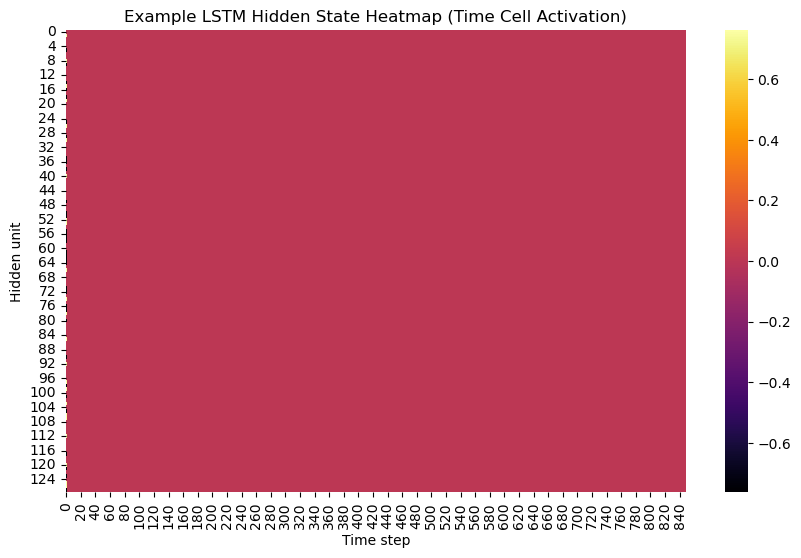

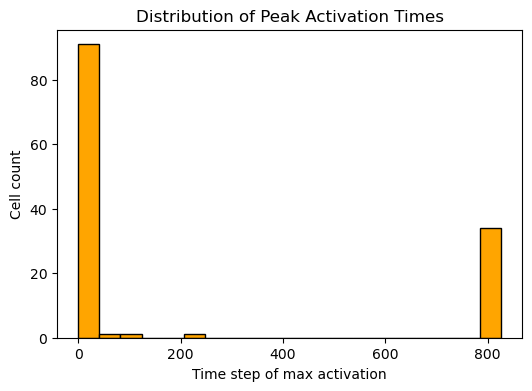

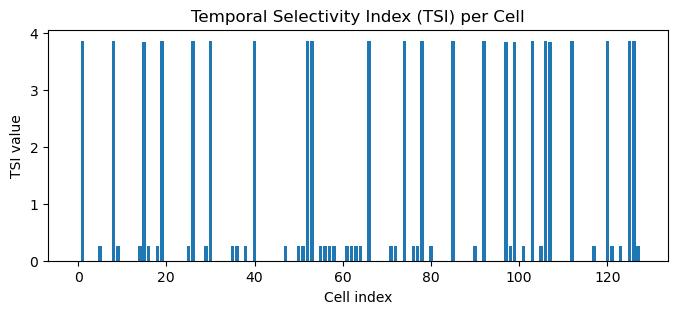

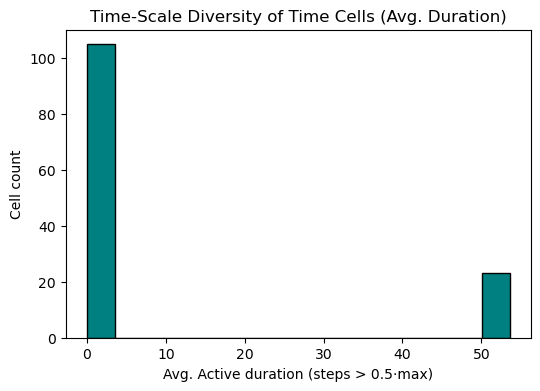

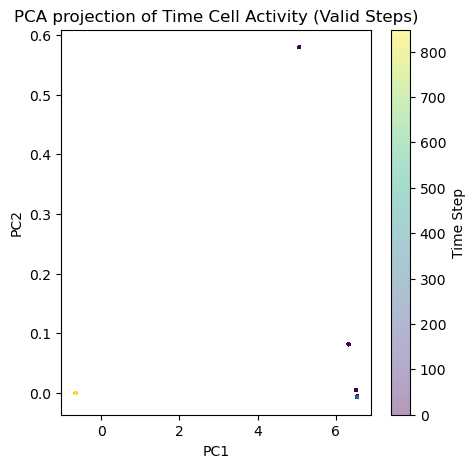

多尺度时间细胞评估完成。

Running Extended Time Cell Evaluations...
Fast=105, Medium=0, Slow=23


/tmp/ipykernel_138999/3220952452.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.array(yaw_data, dtype=np.float32).flatten() # Flatten in case of nested lists/arrays
/tmp/ipykernel_138999/773301823.py:95: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/773301823.py:96: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.savefig(os.path.join(save_dir, "ablation_analysis.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


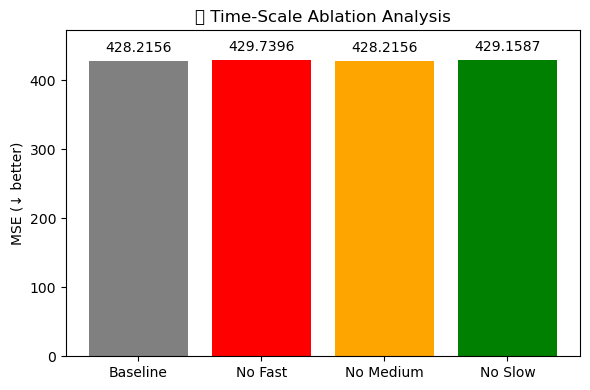

/tmp/ipykernel_138999/773301823.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/773301823.py:110: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.savefig(os.path.join(save_dir, "correlation_matrix.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


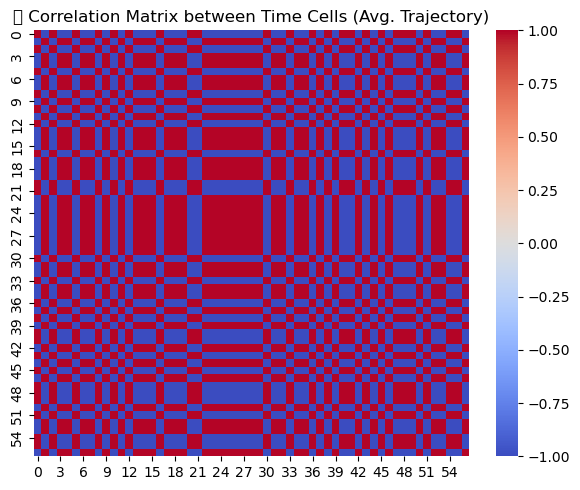

/tmp/ipykernel_138999/773301823.py:151: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/773301823.py:152: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.savefig(os.path.join(save_dir, "multi_scale_filtering.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


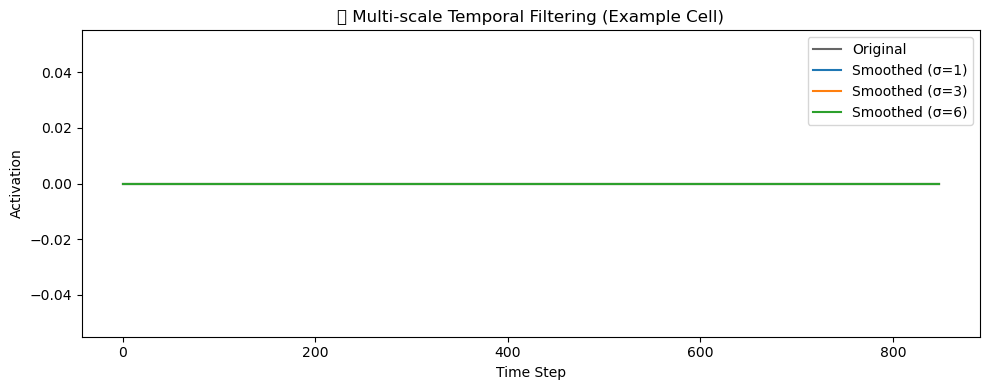

/tmp/ipykernel_138999/773301823.py:175: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/773301823.py:176: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.savefig(os.path.join(save_dir, "cross_traj_corr.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


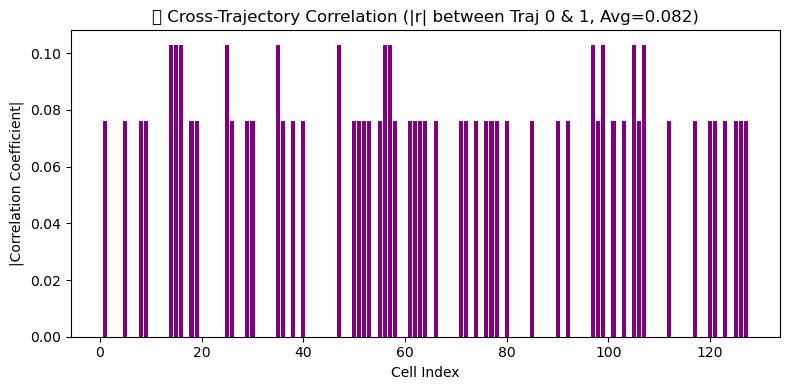

/tmp/ipykernel_138999/3220952452.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.array(yaw_data, dtype=np.float32).flatten() # Flatten in case of nested lists/arrays


✅ Saved evaluation summary to ./eval_results/timecell_eval_summary.csv

Running Trajectory Correlation Evaluation...
✅ Padded trajectory data to shape: pos=(3696, 849, 3), yaw=(3696, 849)


/tmp/ipykernel_138999/766776809.py:109: RuntimeWarning: Mean of empty slice
  corr_pos_mean = np.nanmean(np.abs(corr_pos), axis=1) # Use nanmean
/tmp/ipykernel_138999/766776809.py:126: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/766776809.py:126: UserWarning: Glyph 129517 (\N{COMPASS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/766776809.py:127: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.savefig(os.path.join(save_dir, "cell_position_yaw_corr.png"), dpi=200)
/tmp/ipykernel_138999/766776809.py:127: UserWarning: Glyph 129517 (\N{COMPASS}) missing from current font.
  plt.savefig(os.path.join(save_dir, "cell_position_yaw_corr.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, 

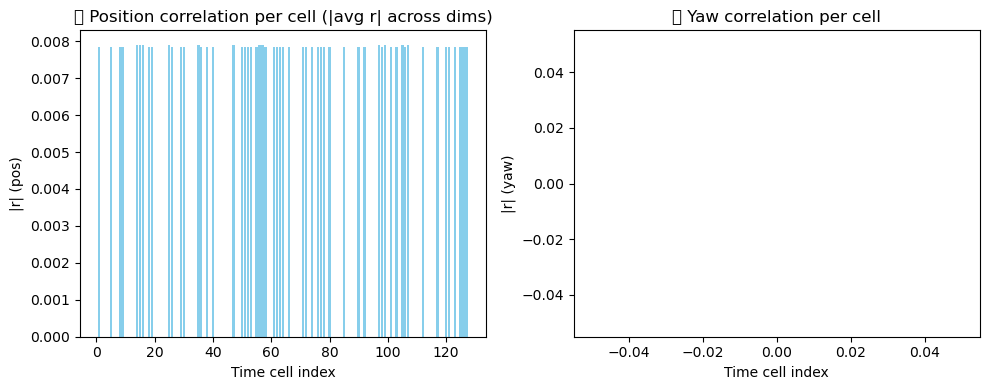

Top 10 position-correlated cells: [ 25  47 105  35  56 107  57  99  97  16]
Top 10 yaw-correlated cells: []


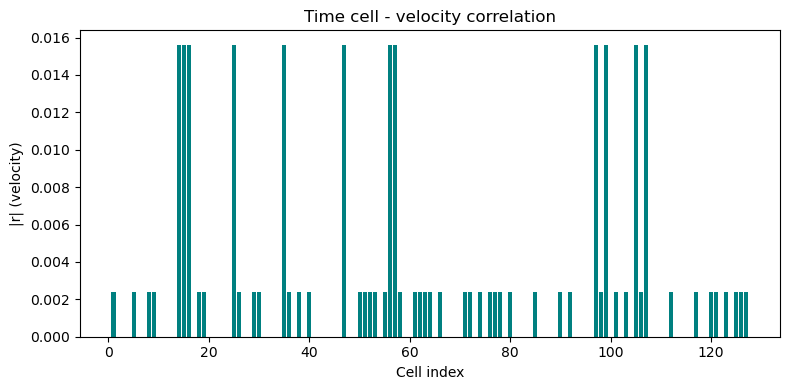

✅ Saved cell-trajectory correlation results to ./eval_results/timecell_traj_corr.csv


/tmp/ipykernel_138999/766776809.py:181: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_138999/766776809.py:182: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.savefig(os.path.join(save_dir, "cell_traj_corr_heatmap.png"), dpi=200)
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


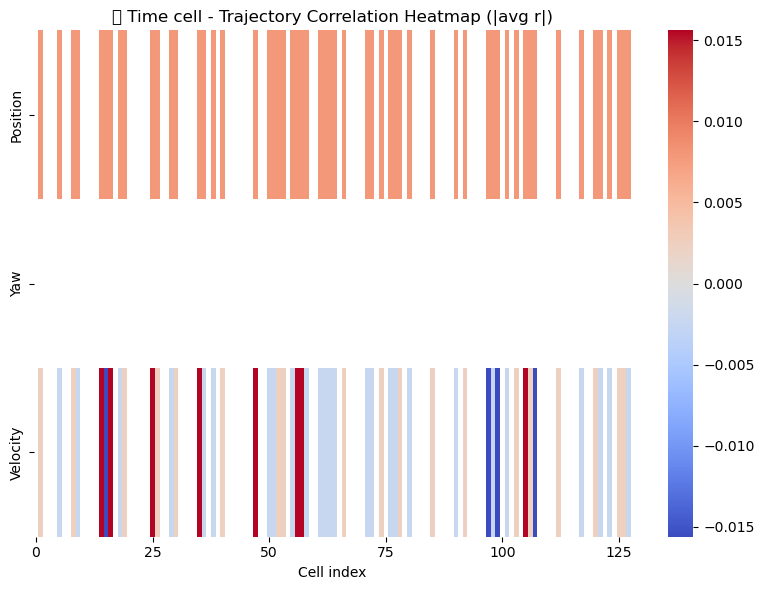


Generating final activation plot...
✅ Saved final activation heatmap to ./eval_results


/tmp/ipykernel_138999/3220952452.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.array(yaw_data, dtype=np.float32).flatten() # Flatten in case of nested lists/arrays


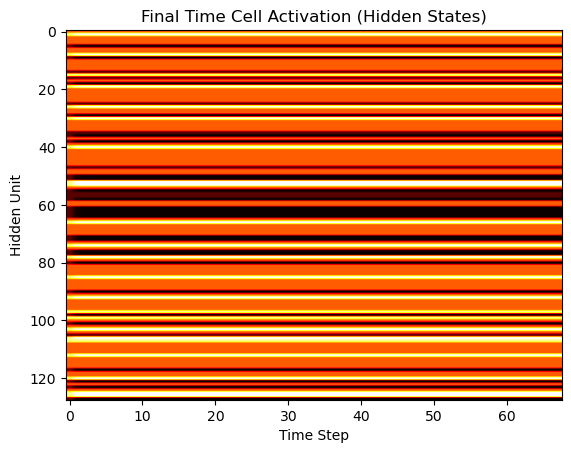


Script finished.


In [9]:
# --- Main Execution Block (Combines Cell 5 and calls) ---
if __name__ == "__main__":

    # --- Configuration ---
    # Consider making this a command-line argument
    DATA_ROOT_DIR = '/media/zhen/Data/Datasets/nomad_data/go_stanford'
    SAVE_DIR = "./eval_results" # Save results in a sub-directory
    BATCH_SIZE = 4
    NUM_EPOCHS = 50 # Set back to a reasonable number for training
    LEARNING_RATE = 1e-3
    HIDDEN_DIM = 128
    VISUAL_DIM = 256
    USE_YAW = True # Set based on your data and model intention
    MIN_LEN = 1

    # --- Initialize Dataset and DataLoader ---
    try:
        print("Initializing dataset...")
        dataset = VariableLengthTrajectoryDataset(DATA_ROOT_DIR, min_len=MIN_LEN, use_yaw=USE_YAW)
        if len(dataset) == 0:
             print(f"Error: No valid trajectories loaded from {DATA_ROOT_DIR}. Exiting.")
             exit()
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_variable_length)
        print("Dataset and DataLoader initialized.")
    except Exception as e:
        print(f"Error during dataset/dataloader initialization: {e}")
        exit()


    # --- Determine correct dimensions from dataset object ---
    input_feat_dim = dataset.input_feature_dim
    output_target_dim = dataset.target_dim
    print(f"Detected input feature_dim = {input_feat_dim}")
    print(f"Detected output target_dim = {output_target_dim}")


    # --- Initialize Model, Optimizer, Loss ---
    print("Initializing model...")
    model = VisualTemporalNet(feature_dim=input_feat_dim,
                              hidden_dim=HIDDEN_DIM,
                              visual_dim=VISUAL_DIM,
                              output_dim=output_target_dim
                             ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    print("Model initialized.")

    # --- Training Loop ---
    print(f"Starting training for {NUM_EPOCHS} epochs...")
    model.train() # Set model to training mode
    for epoch in range(NUM_EPOCHS):
        total_loss = 0
        batch_count = 0
        for batch_data in loader:
             # Unpack batch data
             feats, imgs, targets, mask = batch_data

             # Skip batch if collate_fn returned None due to errors
             if feats is None or imgs is None or targets is None or mask is None:
                 print(f"Skipping problematic batch in epoch {epoch+1}")
                 continue

             # Move data to the selected device
             feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)

             # Forward pass
             try:
                 pred, _ = model(feats, imgs, mask)

                 # Ensure prediction and target shapes match before loss calculation
                 if pred.shape != targets.shape:
                      print(f"Warning: Shape mismatch! Pred: {pred.shape}, Target: {targets.shape}. Skipping batch.")
                      continue # Skip this batch

                 # Loss calculation and backward pass
                 loss = loss_fn(pred, targets)
                 optimizer.zero_grad()
                 loss.backward()
                 optimizer.step()
                 total_loss += loss.item()
                 batch_count += 1

             except Exception as e:
                 print(f"Error during training step in epoch {epoch+1}: {e}")
                 # Decide whether to continue or stop based on the error
                 continue # Skip this batch on error


        if batch_count > 0:
            avg_loss = total_loss / batch_count
            print(f'Epoch {epoch+1}, Average Loss={avg_loss:.4f}')
        else:
             print(f"Epoch {epoch+1} had no valid batches.")

    print("Training finished.")

    # --- Run Analyses ---
    print("\nRunning Time Cell Analysis...")
    try:
         # Need to create a new loader if the old one is exhausted or shuffling is desired differently for analysis
         # For simplicity, re-using the same loader instance here. If issues arise, create a new one.
         analysis_results = analyze_time_cells(model, loader, device) # Pass device
    except Exception as e:
         print(f"Error during analyze_time_cells: {e}")
         analysis_results = None # Ensure it's None if analysis fails


    if analysis_results:
        print("\nRunning Extended Time Cell Evaluations...")
        try:
             extended_analysis_results = evaluate_time_scales_and_extensions(model, loader, analysis_results, device, save_dir=SAVE_DIR) # Pass device
        except Exception as e:
            print(f"Error during evaluate_time_scales_and_extensions: {e}")
            extended_analysis_results = None

        print("\nRunning Trajectory Correlation Evaluation...")
        try:
            trajectory_correlation_results = evaluate_timecell_trajectory_correlation(model, loader, analysis_results, device, save_dir=SAVE_DIR) # Pass device
        except Exception as e:
             print(f"Error during evaluate_timecell_trajectory_correlation: {e}")
             trajectory_correlation_results = None

    else:
        print("Skipping extended evaluations due to failure in initial analysis.")


    # --- Final Plotting (Optional - can be done from saved files too) ---
    print("\nGenerating final activation plot...")
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
         # Get a fresh batch for plotting if loader might be exhausted
         try:
              plot_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_variable_length) # Use non-shuffled loader
              feats, imgs, targets, mask = next(iter(plot_loader))
         except StopIteration:
              print("Warning: Could not get a new batch for final plotting.")
              feats, imgs, targets, mask = None, None, None, None # Set to None


         if feats is not None:
              # Move data to GPU for inference
              feats_gpu = feats.to(device)
              imgs_gpu = imgs.to(device)
              mask_gpu = mask.to(device)

              _, lstm_out_gpu = model(feats_gpu, imgs_gpu, mask_gpu)

              # Move the result back to CPU for plotting
              lstm_out_cpu = lstm_out_gpu.cpu().numpy()

              plt.figure() # Create a new figure explicitly
              plt.imshow(lstm_out_cpu[0].T, aspect='auto', cmap='hot')
              plt.title('Final Time Cell Activation (Hidden States)')
              plt.xlabel('Time Step')
              plt.ylabel('Hidden Unit')
              plt.savefig(os.path.join(SAVE_DIR, "final_activation_heatmap.png"), dpi=200)
              print(f"✅ Saved final activation heatmap to {SAVE_DIR}")
              plt.show() # Show plot if running interactively
         else:
             print("Skipping final activation plot.")

    print("\nScript finished.")